In [1]:
from pqc_iot_simulator.pqc_iot_sim.components import Network, Logger
from pqc_iot_simulator.pqc_iot_sim.engines import MininetWiFiEngine

Logger.activate()

16:32:08 | Logger ativado


In [2]:
CRYPTO_MODE = "classical"

SOURCE = "iot_1"
DESTINATION = "server_1"

PAYLOAD = {
    "sensor": "temperatura",
    "valor": 28.5,
    "unidade": "celsius",
    "mensagem": "teste classico no jupyter"
}


16:32:08 | Coletor de metricas criado e pronto para registrar transmissoes
16:32:08 | CryptoManager criado
16:32:08 | Rede default_network criada e pronta para configuracao
16:32:08 | Metricas apagadas e contador de transmissoes reiniciado
16:32:08 | Topologia grade criada com sucesso, 9 nos e 12 links


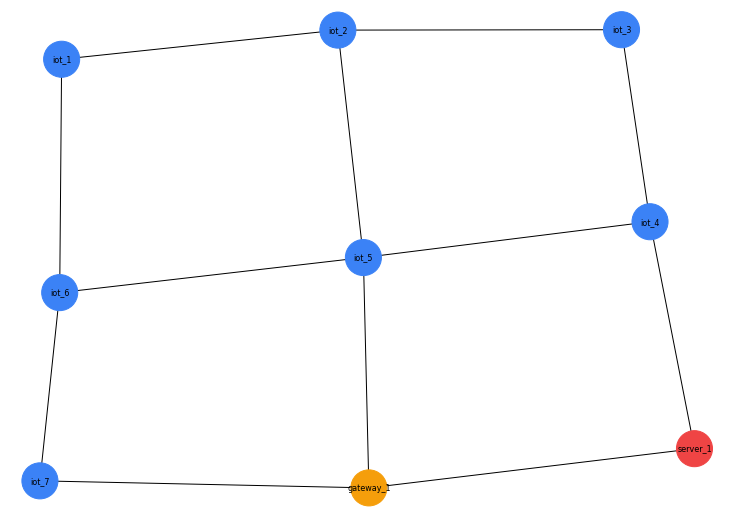

In [ ]:
rede = Network(verbose=True)
rede.set_ready_topology("grade", 3, 3)
rede.draw();

In [4]:
rede.set_protocol("mqtt")
rede.set_crypto_mode(CRYPTO_MODE);

16:32:08 | CryptoManager configurado


In [5]:
engine = MininetWiFiEngine(
    network=rede,
    logger=rede.logger,
    default_bw=10,
    default_delay="5ms",
    default_loss=0,
    link_mode="infrastructure",
    open_cli_on_start=False
)

print("Engine criada")

16:32:08 | Engine mininet_wifi_engine criada, tipo: mininet_wifi
16:32:08 | Engine mininet_wifi_engine configurada, parametros: ip_base: 10.0.0., ip_prefix: 24, ssid: pqc_iot_sim, mode: g, channel: 1, default_bw: 10, default_delay: 5ms, default_loss: 0, auto_set_positions: True, open_cli_on_start: False, link_mode: infrastructure, station_range: 200, ap_range: 200, association_wait_seconds: 1.0
16:32:08 | Engine Mininet WiFi criada, modo de link: infrastructure, SSID: pqc_iot_sim
Engine criada


In [6]:
engine.build()
engine.start()

print("Engine iniciada")

16:32:08 | Network validada para a engine, nos: 9, links: 12
16:32:08 | 9 nos mapeados para a engine
16:32:08 | Engine preparada, nos mapeados: 9, links mapeados: 1
16:32:08 | Construindo rede no Mininet WiFi, nos: 9, links: 1, modo de link: infrastructure
16:32:08 | Objeto de runtime registrado, chave: net, tipo: Mininet_wifi
16:32:08 | Objeto de runtime registrado, chave: controller, tipo: Controller
16:32:08 | Objeto de runtime registrado, chave: iot_1, tipo: Station
16:32:08 | Objeto de runtime registrado, chave: iot_2, tipo: Station
16:32:08 | Objeto de runtime registrado, chave: iot_3, tipo: Station
16:32:08 | Objeto de runtime registrado, chave: iot_6, tipo: Station
16:32:08 | Objeto de runtime registrado, chave: iot_5, tipo: Station
16:32:08 | Objeto de runtime registrado, chave: iot_4, tipo: Station
16:32:08 | Objeto de runtime registrado, chave: iot_7, tipo: Station
16:32:08 | Objeto de runtime registrado, chave: gateway_1, tipo: OVSAP
16:32:08 | Objeto de runtime registrado,

*** sta1-wlan0: requested 200.00m -> effective 200.00m (delta +0.00m) using tx power 9 dBm
*** sta2-wlan0: requested 200.00m -> effective 200.00m (delta +0.00m) using tx power 9 dBm
*** sta3-wlan0: requested 200.00m -> effective 200.00m (delta +0.00m) using tx power 9 dBm
*** sta6-wlan0: requested 200.00m -> effective 200.00m (delta +0.00m) using tx power 9 dBm
*** sta5-wlan0: requested 200.00m -> effective 200.00m (delta +0.00m) using tx power 9 dBm
*** sta4-wlan0: requested 200.00m -> effective 200.00m (delta +0.00m) using tx power 9 dBm
*** sta7-wlan0: requested 200.00m -> effective 200.00m (delta +0.00m) using tx power 9 dBm
*** ap1-wlan1: requested 200.00m -> effective 200.00m (delta +0.00m) using tx power 9 dBm
(10.00Mbit 5ms delay 0.00000% loss) (10.00Mbit 5ms delay 0.00000% loss) 

16:32:12 | 1 links criados no Mininet WiFi
16:32:12 | Engine mininet_wifi_engine marcada como construida
16:32:12 | Build do Mininet WiFi concluido, stations: 7, gateways: 1, servidores: 1, links: 1, modo de link: infrastructure
16:32:12 | Iniciando rede Mininet WiFi


sta1 is already connected!


16:32:12 | Engine mininet_wifi_engine iniciada em 2026/04/28 16:32:12
16:32:12 | Mininet WiFi iniciado com sucesso, access points ativos: ap1


sta2 is already connected!
sta3 is already connected!
sta6 is already connected!
sta5 is already connected!
sta4 is already connected!
sta7 is already connected!


16:32:19 | Stations associadas aos access points, stations: 7, APs: ap1, estrategia: round robin
16:32:21 | Configuracao de conectividade aplicada, modo de link: infrastructure, stations associadas aos APs, interfaces WiFi ativadas e encaminhamento L2 configurado
Engine iniciada


In [7]:
link_metrics = engine.collect_link_metrics(
    source=SOURCE,
    destination=DESTINATION
)

print(link_metrics)

16:32:23 | Metricas reais de link coletadas entre iot_1 e server_1, IP destino: 10.0.0.200, latencia: 12.606 ms, perda de pacotes: 0.0%, pacotes enviados: 3, pacotes recebidos: 3
{'source': 'iot_1', 'destination': 'server_1', 'destination_ip': '10.0.0.200', 'packet_loss_percent': 0.0, 'packets_transmitted': 3, 'packets_received': 3, 'rtt_min_ms': 9.281, 'rtt_avg_ms': 12.606, 'rtt_max_ms': 18.996, 'rtt_mdev_ms': 4.519, 'latency_ms': 12.606, 'raw_output': 'PING 10.0.0.200 (10.0.0.200) 56(84) bytes of data.\r\n64 bytes from 10.0.0.200: icmp_seq=1 ttl=64 time=19.0 ms\r\n64 bytes from 10.0.0.200: icmp_seq=2 ttl=64 time=9.28 ms\r\n64 bytes from 10.0.0.200: icmp_seq=3 ttl=64 time=9.54 ms\r\n\r\n--- 10.0.0.200 ping statistics ---\r\n3 packets transmitted, 3 received, 0% packet loss, time 2001ms\r\nrtt min/avg/max/mdev = 9.281/12.606/18.996/4.519 ms\r\n'}


In [8]:
send_result = rede.send(
    source=SOURCE,
    destination=DESTINATION,
    payload=PAYLOAD,
    link_metrics=link_metrics
)

16:32:23 | IOT 1 criado e inicializado, energia: 100, protocolo: mqtt, modo de criptografia: classica
16:32:23 | IOT 2 criado e inicializado, energia: 100, protocolo: mqtt, modo de criptografia: classica
16:32:23 | IOT 3 criado e inicializado, energia: 100, protocolo: mqtt, modo de criptografia: classica
16:32:23 | IOT 6 criado e inicializado, energia: 100, protocolo: mqtt, modo de criptografia: classica
16:32:23 | IOT 5 criado e inicializado, energia: 100, protocolo: mqtt, modo de criptografia: classica
16:32:23 | IOT 4 criado e inicializado, energia: 100, protocolo: mqtt, modo de criptografia: classica
16:32:23 | IOT 7 criado e inicializado, energia: 100, protocolo: mqtt, modo de criptografia: classica
16:32:23 | Gateway 1 criado e inicializado, energia: 500, protocolo: mqtt, modo de criptografia: classica
16:32:23 | Servidor 1 criado e inicializado, energia: 1000, protocolo: mqtt, modo de criptografia: classica
16:32:23 | 9 hosts criados com sucesso
16:32:23 | Enviando pacote de iot

In [9]:
summary = rede.metrics()

print(summary)

{'total_transmissions': 1, 'delivered': 1, 'failed': 0, 'delivery_rate': 1.0, 'total_energy_consumed': 0.637129, 'average_energy_consumed': 0.637129, 'average_hops': 4.0, 'average_duration_seconds': 0.094047, 'total_payload_bytes': 307, 'total_original_payload_bytes': 103, 'total_protected_payload_bytes': 307, 'total_crypto_overhead_bytes': 188, 'average_crypto_overhead_bytes': 188.0, 'total_crypto_time_seconds': 0.093119, 'average_crypto_time_seconds': 0.093119, 'total_crypto_energy_cost': 0.097129, 'average_crypto_energy_cost': 0.097129, 'average_link_latency_ms': 12.606, 'average_link_packet_loss_percent': 0.0, 'total_link_packets_transmitted': 3, 'total_link_packets_received': 3, 'link_delivery_rate': 1.0}


In [10]:
transmissions = rede.transmissions()

if transmissions:
    print(transmissions[0])
else:
    print("Nenhuma transmissão registrada")

{'transmission_id': 1, 'source': 'iot_1', 'destination': 'server_1', 'status': 'delivered', 'delivered': True, 'path': ['iot_1', 'iot_2', 'iot_3', 'iot_4', 'server_1'], 'hops': 4, 'protocol': 'mqtt', 'crypto_mode': 'classical', 'payload_size_bytes': 307, 'original_payload_size_bytes': 103, 'protected_payload_size_bytes': 307, 'crypto_backend': 'cryptography', 'crypto_algorithm': 'X25519 + Ed25519 + AES GCM', 'crypto_original_size_bytes': 103, 'crypto_protected_size_bytes': 307, 'crypto_overhead_bytes': 188, 'crypto_time_seconds': 0.093119, 'crypto_energy_cost': 0.097129, 'crypto_metadata': {'classical_kex': {'algorithm': 'X25519', 'sender_public_key_size': 32, 'receiver_public_key_size': 32, 'shared_secret_size': 32, 'shared_secret_valid': True}, 'classical_signature': {'algorithm': 'Ed25519', 'public_key_size': 32, 'signature_size': 64, 'signature_valid': True}, 'encryption': {'algorithm': 'AES GCM', 'nonce': 'lIZjQLqkJDn2Okv0', 'ciphertext': 'hmo+/T7p0BdSdyH31DPU7JXhvCJldvLnOXFDU3qPP

In [11]:
engine.stop()

print("Engine parada")

16:32:23 | Parando rede Mininet WiFi


*** Stopping 1 controllers
c0 
*** Stopping 9 links
.........
*** Stopping switches/access points
ap1 
*** Stopping nodes
h1 sta1 sta2 sta3 sta6 sta5 sta4 sta7 

*** Removing WiFi module and Configurations
*** Killing mac80211_hwsim

*** Done


16:32:25 | Engine mininet_wifi_engine parada em 2026/04/28 16:32:25
16:32:25 | Mininet WiFi parado com sucesso
Engine parada
